In [2]:
!pip install numpy pandas scikit-learn gensim

In [3]:
import pandas as pd

# 读取文本文件
with open(r'C:\Users\owner\Desktop\KG\OneNYC_2050_Strategic_Plan_final.txt', 'r', encoding='utf-8') as file:
    documents = file.readlines()

# 简单预处理（移除空行）
documents = [doc.strip() for doc in documents if doc.strip()]

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\owner\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\owner\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Topic 0: housing, economic, growth, education, economy, businesses, residents, population, services, many
Topic 1: projects, parks, project, capital, planning, source, park, bus, improve, construction
Topic 2: residents, mayor, report, government, help, immigrants, violence, voter, federal, democracy
Topic 3: fair, strong, building, infrastructure, climate, healthy, education, needs, equity, democracy
Topic 4: climate, emissions, reduce, change, transportation, vehicles, energy, infrastructure, carbon, transit
Topic 5: climate, programs, cities, global, local, training, officers, help, program, education
Topic 6: waste, buildings, emissions, energy, carbon, including, climate, expand, organics, reduce
Topic 7: service, mayor, program, services, social, projects, free, mental, join, expand
Topic 8: funded, housing, indicators, partially, district, status, initiative, affordable, plan, target
Topic 9: mortality, equity, climate, program, teachers, agencies, source, water, lgbtq, disease


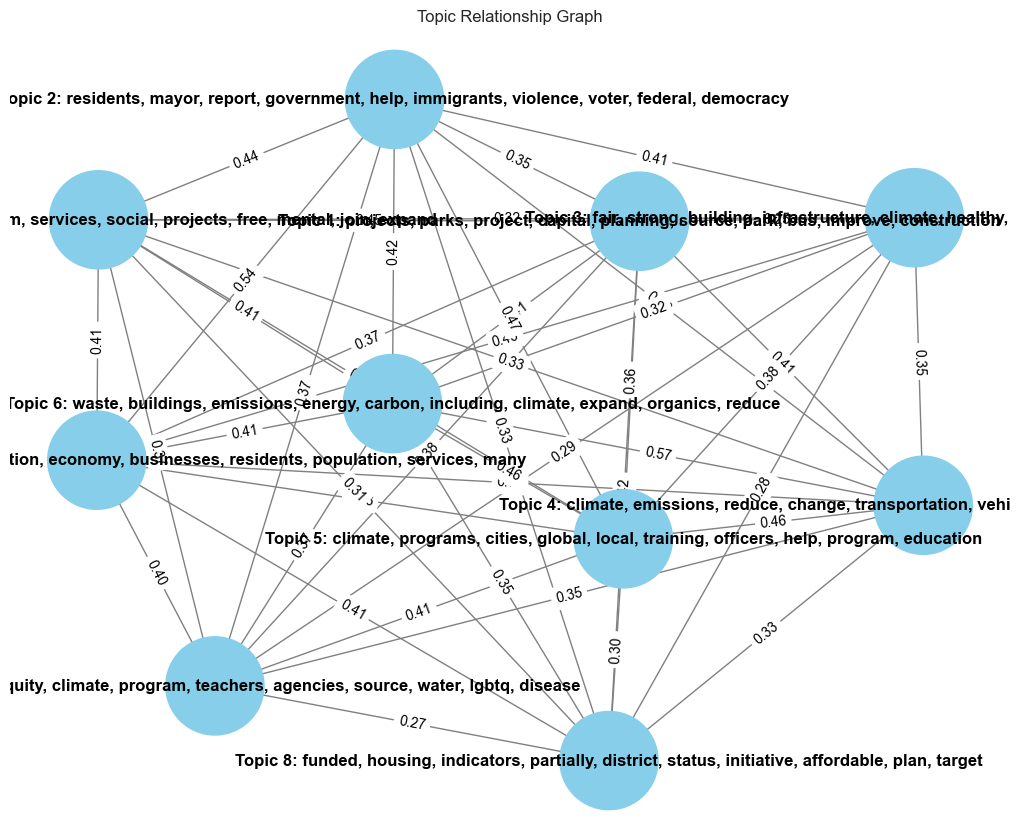

In [4]:
from gensim import corpora
from gensim.models import LdaModel, Phrases
from nltk.tokenize import word_tokenize
import nltk
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.metrics.pairwise import cosine_similarity
from nltk.corpus import stopwords

nltk.download('punkt')
nltk.download('stopwords')

def remove_new_york_city(text):
    # 替换 "new york city" 为 "newyorkcity"（避免拆分），然后进行分词
    text = text.replace("new york city", "newyorkcity")
    words = text.split()
    return [word for word in words if word.lower() not in stop_words or word.lower() == "newyorkcity"]

# 定义并更新停用词列表
stop_words = set(stopwords.words('english'))
stop_words.update(["new", "new york","city","students","us","we","since","chief","black","white","bill", "students", "families", "nyc", "york", "public", "community", "communities", "health", "yorker", "yorkers", "state", "onenyc", "2050", "mayor"',"residents',"neighborhood", "also","access","achieve","get","college","children","people","department", "office", "neighborhoods", "school", "schools", "jobs", "care", "increase", "must", "support","end","one","two","three","and","in","on","at","dot","data","high","low","percent","use","mta","fleet","first","second","third","funding","volume","food","e"])
stop_words = list(stop_words)

# 处理文档数据：去除空行并分词
documents = [doc.strip() for doc in documents if doc.strip()]
tokenized_docs = [word_tokenize(doc.lower()) for doc in documents]
tokenized_docs = [[word for word in doc if word.isalpha() and word not in stop_words] for doc in tokenized_docs]

# 设置种子主题
seed_topics = [
    ['adaptive capacity', 'adaptive','adaptation','adapt', 'adjustment ability', 'adaptation capacity', 'flexibility', 'resilience', 'adaptation', 'coping ability', 'adaptive response', 'climate resilience', 'adaptive management', 'adaptation strategies', 'capacity to adapt', 'system adaptability'],
    ['climate proofing', 'climate proofing', 'climate resilience', 'climate adaptation', 'climate change adaptation', 'climate resilience strategies', 'climate protection', 'climate-smart infrastructure', 'resilient infrastructure', 'climate adaptation measures', 'climate change mitigation'],
    ['vulnerability assessment', 'vulnerability','vulnerable', 'vulnerability analysis', 'risk assessment', 'impact assessment', 'climate risk evaluation', 'climate vulnerability', 'threat analysis', 'hazard assessment', 'vulnerability mapping', 'climate risk analysis', 'resilience assessment'],
    ['ecosystem-based adaptation', 'ecosystem adaptative', 'ecosystem resilience', 'ecosystem change', 'ecosystem', 'ecological adaptation', 'ecosystem response', 'ecological resilience', 'ecosystem transformation', 'environmental adaptation', 'ecosystem sustainability', 'ecosystem-based adaptation', 'ecosystem management'],
    ['resilience', 'resilience', 'resilient', 'adaptive capacity', 'toughness', 'durability', 'robustness', 'resiliency', 'recovery ability', 'strength', 'sustainability', 'robust system', 'climate resilience', 'disaster resilience', 'resilient systems', 'adaptive resilience', 'resilience building'],
    ['transportation planning', 'transportation planning', 'public transport', 'transportation', 'transport', 'public transit', 'transport infrastructure', 'transportation systems', 'urban transport'],
    ['zoning', 'land use regulation', 'urban zoning', 'zoning laws', 'land use planning', 'urban land use', 'land zoning', 'zoning ordinances', 'zoning policies', 'land use regulations', 'zoning codes', 'land use management', 'urban zoning policies', 'spatial zoning'],
    ['urban design', 'design', 'urban development', 'urban form', 'urban planning', 'built environment', 'renewal', 'city layout', 'urban architecture', 'urban planning design', 'sustainable urban design', 'urban space design', 'landscape'],
    ['sustainable development', 'sustainable development', 'sustainability', 'green development', 'sustainable growth', 'eco-friendly development', 'environmental sustainability', 'eco-development', 'green growth', 'environmentally sustainable development', 'sustainable urban development', 'low-carbon development', 'social sustainability', 'economic sustainability', 'sustainability initiatives'],
    ['land use planning', 'land use', 'urban land', 'land development', 'land management', 'land allocation', 'urban land use', 'spatial planning', 'land use policies', 'land planning', 'territorial planning', 'land use zoning', 'land use strategy', 'urban land management', 'land use regulations', 'land use planning policies']
]

# 创建词典和语料
dictionary = corpora.Dictionary(tokenized_docs)
corpus = [dictionary.doc2bow(doc) for doc in tokenized_docs]

# 创建 LDA 模型
lda_model = LdaModel(corpus=corpus, id2word=dictionary, num_topics=len(seed_topics), passes=40, iterations=400, alpha=0.1, random_state=42)

# 提取每个主题的前 top_n_words 个关键词
top_n_words = 10
topic_labels = []

# 获取每个主题的关键词
for i in range(len(lda_model.state.get_lambda())):
    top_words_idx = lda_model.get_topic_terms(i, topn=top_n_words)
    top_words = [dictionary[word_id] for word_id, _ in top_words_idx]
    topic_labels.append(f"Topic {i}: " + ", ".join(top_words))

# 打印主题标签
for label in topic_labels:
    print(label)

# 计算主题之间的相似度（余弦相似度）
topic_word_distributions = lda_model.get_topics()
topic_similarity = cosine_similarity(topic_word_distributions)

# 构建图
G = nx.Graph()
for i in range(len(topic_similarity)):
    for j in range(i + 1, len(topic_similarity)):
        G.add_edge(f"Topic {i}", f"Topic {j}", weight=topic_similarity[i, j])

# 绘制网络图
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, k=0.5)  # 定义布局
node_sizes = [len(topic.split(":")[1].split(", ")) * 500 for topic in topic_labels]

nx.draw(
    G, pos, with_labels=True, labels=dict(zip(G.nodes, topic_labels)),
    node_color="skyblue", font_weight="bold", edge_color="gray",
    node_size=node_sizes, font_size=12
)

# 添加边的权重
edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10)

plt.title("Topic Relationship Graph")
plt.show()

C:\Users\owner\AppData\Local\Temp\ipykernel_16304\3895500394.py:41: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  nx.draw_networkx_edges(


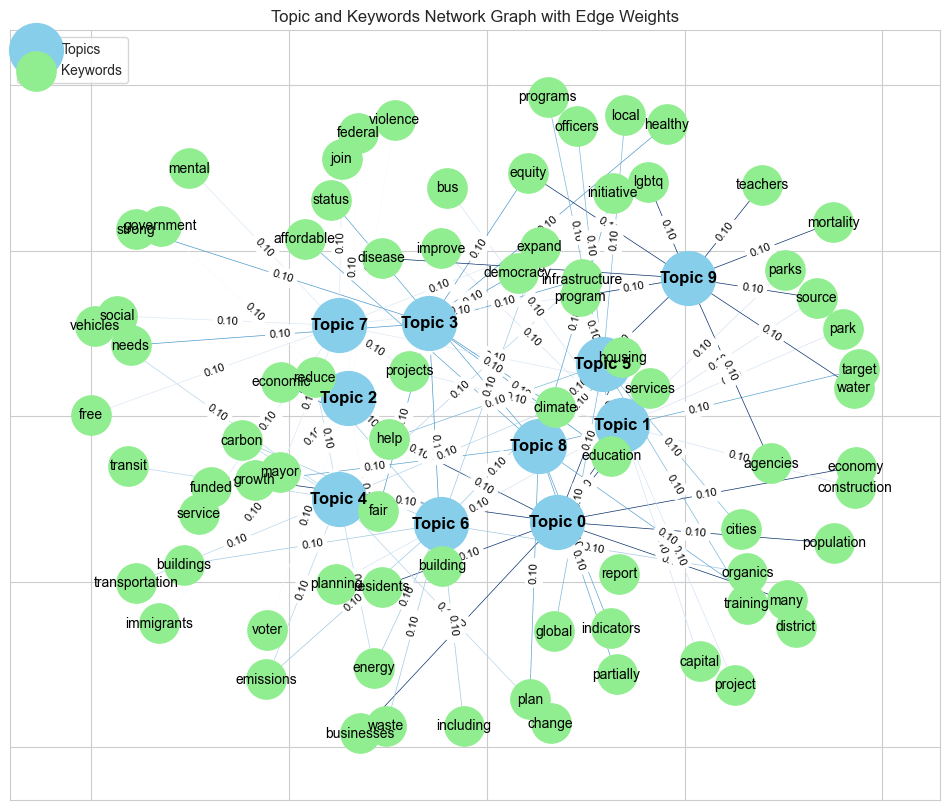

In [5]:
# 构建图，将主题和关键词分离，并添加权重
G1 = nx.Graph()

for i, label in enumerate(topic_labels):
    topic_node = f"Topic {i}"  # 中心节点
    G1.add_node(topic_node, type="topic")  # 标记为主题节点
    for word in label.split(": ")[1].split(", "):  # 获取关键词
        G1.add_node(word, type="word")  # 添加关键词节点
        weight = topic_similarity[i, i] / (len(label.split(": ")[1].split(", ")) + 1e-5)  # 避免除零错误
        G1.add_edge(topic_node, word, weight=weight)  # 连接到主题节点

# 获取所有边的权重并进行缩放，以便在图中可见
edges = G1.edges(data=True)
weights = [d['weight'] for _, _, d in edges]

# 对权重进行缩放处理，确保边的宽度在绘图时可见
max_weight = max(weights)
#scaled_weights = [w / max_weight for w in weights]  # 归一化到 [0, 1] 区间
scaled_weights=weights
# 绘制网络图
plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G1, k=0.3)  # 定义布局参数

# 分离主题节点和关键词节点，设置不同的样式
topic_nodes = [node for node, attr in G1.nodes(data=True) if attr['type'] == 'topic']
word_nodes = [node for node, attr in G1.nodes(data=True) if attr['type'] == 'word']

# 绘制主题节点
nx.draw_networkx_nodes(G1, pos, nodelist=topic_nodes, node_color="skyblue", node_size=1500, label="Topics")
nx.draw_networkx_labels(G1, pos, labels={node: node for node in topic_nodes}, font_size=12, font_weight="bold")

# 绘制关键词节点
nx.draw_networkx_nodes(G1, pos, nodelist=word_nodes, node_color="lightgreen", node_size=800, label="Keywords")
nx.draw_networkx_labels(G1, pos, labels={node: node for node in word_nodes}, font_size=10)

# 绘制边，并根据权重调整宽度和颜色
nx.draw_networkx_edges(
    G1, pos, edgelist=edges, edge_color=scaled_weights, edge_cmap=plt.cm.Blues, width=[w * 5 for w in scaled_weights]
)

# 添加边的权重标签
edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in edges}
nx.draw_networkx_edge_labels(G1, pos, edge_labels=edge_labels, font_size=8)

plt.title("Topic and Keywords Network Graph with Edge Weights")
plt.legend(scatterpoints=1, loc="upper left")
plt.show()


In [6]:
import numpy as np

# 获取所有主题和关键词节点
topic_nodes = [f"Topic {i}" for i in range(len(topic_labels))]
word_nodes = set()  # 使用集合避免重复关键词
for label in topic_labels:
    word_nodes.update(label.split(": ")[1].split(", "))
word_nodes = list(word_nodes)

# 初始化权重矩阵
weight_matrix = np.zeros((len(topic_nodes), len(word_nodes)))

# 填充权重矩阵
for i, topic in enumerate(topic_nodes):
    for j, word in enumerate(word_nodes):
        if G1.has_edge(topic, word):
            weight_matrix[i, j] = G1[topic][word]['weight']

# 输出权重矩阵
print("Weight Matrix:")
print(weight_matrix)


Weight Matrix:
[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.10000333 0.         0.         0.
  0.         0.         0.         0.         0.         0.10000333
  0.10000333 0.         0.         0.         0.         0.
  0.         0.         0.10000333 0.         0.         0.10000333
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.10000333 0.         0.
  0.         0.         0.         0.         0.10000333 0.
  0.         0.         0.         0.         0.         0.
  0.         0.10000333 0.         0.         0.         0.
  0.10000333 0.10000333 0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.09999654
  0.         0.         0.         0.         0.         0.
  0.09999654 0.         0.         0.         0.         0.
  0

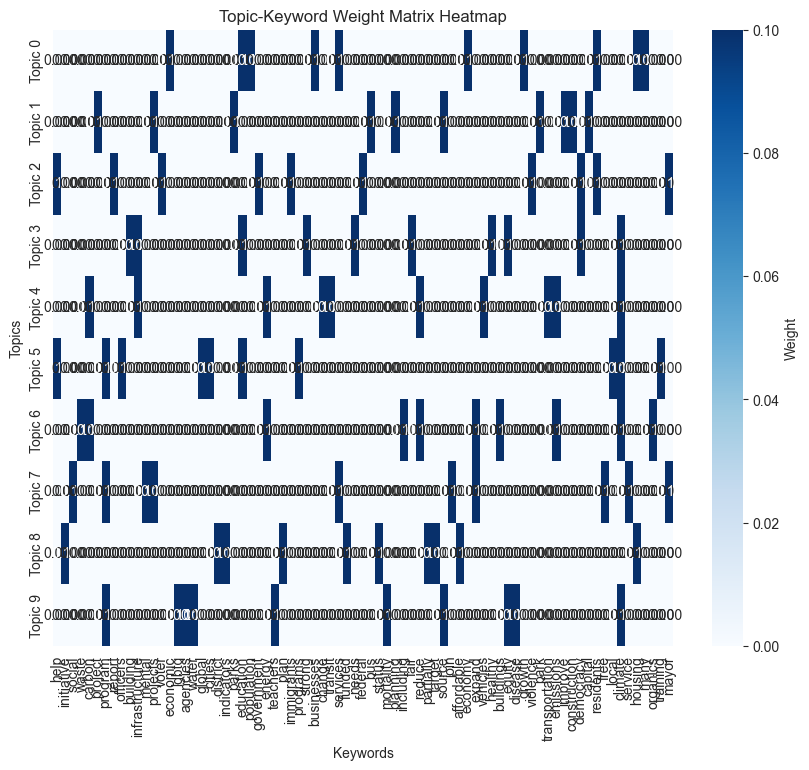

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 创建权重矩阵（如果使用 Pandas DataFrame）
weight_matrix = np.zeros((len(topic_nodes), len(word_nodes)))

# 填充权重矩阵
for i, topic in enumerate(topic_nodes):
    for j, word in enumerate(word_nodes):
        if G1.has_edge(topic, word):
            weight_matrix[i, j] = G1[topic][word]['weight']

# 可视化权重矩阵为热图
plt.figure(figsize=(10, 8))
sns.heatmap(weight_matrix, xticklabels=word_nodes, yticklabels=topic_nodes,
            cmap='Blues', annot=True, fmt=".2f", cbar_kws={'label': 'Weight'})

plt.title("Topic-Keyword Weight Matrix Heatmap")
plt.xlabel("Keywords")
plt.ylabel("Topics")
plt.show()


In [8]:
topic_labels

['Topic 0: housing, economic, growth, education, economy, businesses, residents, population, services, many',
 'Topic 1: projects, parks, project, capital, planning, source, park, bus, improve, construction',
 'Topic 2: residents, mayor, report, government, help, immigrants, violence, voter, federal, democracy',
 'Topic 3: fair, strong, building, infrastructure, climate, healthy, education, needs, equity, democracy',
 'Topic 4: climate, emissions, reduce, change, transportation, vehicles, energy, infrastructure, carbon, transit',
 'Topic 5: climate, programs, cities, global, local, training, officers, help, program, education',
 'Topic 6: waste, buildings, emissions, energy, carbon, including, climate, expand, organics, reduce',
 'Topic 7: service, mayor, program, services, social, projects, free, mental, join, expand',
 'Topic 8: funded, housing, indicators, partially, district, status, initiative, affordable, plan, target',
 'Topic 9: mortality, equity, climate, program, teachers, ag

In [9]:
word_nodes

['help',
 'initiative',
 'social',
 'waste',
 'carbon',
 'project',
 'program',
 'report',
 'officers',
 'building',
 'infrastructure',
 'mental',
 'projects',
 'voter',
 'economic',
 'lgbtq',
 'agencies',
 'water',
 'global',
 'cities',
 'district',
 'indicators',
 'parks',
 'education',
 'population',
 'government',
 'energy',
 'teachers',
 'plan',
 'immigrants',
 'programs',
 'strong',
 'businesses',
 'change',
 'transit',
 'services',
 'funded',
 'needs',
 'federal',
 'bus',
 'status',
 'mortality',
 'planning',
 'including',
 'fair',
 'reduce',
 'partially',
 'target',
 'source',
 'join',
 'affordable',
 'economy',
 'expand',
 'vehicles',
 'healthy',
 'buildings',
 'equity',
 'disease',
 'growth',
 'violence',
 'park',
 'transportation',
 'emissions',
 'improve',
 'construction',
 'democracy',
 'capital',
 'residents',
 'free',
 'local',
 'climate',
 'service',
 'housing',
 'many',
 'organics',
 'training',
 'mayor']

权重计算扩展
可以根据以下方法增强权重计算：

TF-IDF：衡量关键词的重要性。
Jaccard 相似度：计算固定节点关键词集与 LDA 关键词集的相似度。
嵌入向量相似度：将关键词映射到词嵌入空间，计算余弦相似度。

In [10]:
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# 固定节点列表和关键词
fixed_nodes_list = {
    'resilience': ['resilience', 'resilient', 'adaptive capacity', 'toughness', 'durability', 'robustness', 'resiliency', 'recovery ability', 'strength', 'sustainability', 'robust system', 'climate resilience', 'disaster resilience', 'resilient systems', 'adaptive resilience', 'resilience building'],
    'adaptive capacity': ['adaptive','adaptation','adapt', 'adjustment ability', 'adaptation capacity', 'flexibility', 'resilience', 'adaptation', 'coping ability', 'adaptive response', 'climate resilience', 'adaptive management', 'adaptation strategies', 'capacity to adapt', 'system adaptability'],
    'vulnerability assessment': ['vulnerability','vulnerable', 'vulnerability analysis', 'risk assessment', 'impact assessment', 'climate risk evaluation', 'climate vulnerability', 'threat analysis', 'hazard assessment', 'vulnerability mapping', 'climate risk analysis', 'resilience assessment'],
    'climate proofing': ['climate proofing', 'climate resilience', 'climate adaptation', 'climate change adaptation', 'climate resilience strategies', 'climate protection', 'climate-smart infrastructure', 'resilient infrastructure', 'climate adaptation measures', 'climate change mitigation'],
    'ecosystem-based adaptation': ['ecosystem adaptative', 'ecosystem resilience', 'ecosystem change', 'ecosystem', 'ecological adaptation', 'ecosystem response', 'ecological resilience', 'ecosystem transformation', 'environmental adaptation', 'ecosystem sustainability', 'ecosystem-based adaptation', 'ecosystem management'],
    'zoning': ["district", "area management",'urban zoning', 'district policies', 'district regulations', 'zoning codes', 'land use management', 'urban zoning policies', 'spatial zoning'],
    'land use planning': ['land use', 'urban land', 'land development', 'land management', 'land allocation', 'urban land use', 'spatial planning', 'land use policies', 'land planning', 'territorial planning', 'land use zoning', 'land use strategy', 'urban land management', 'land use regulations', 'land use planning policies'],
    'urban design': ['design', 'urban development', 'urban form', 'urban planning', 'built environment', 'renewal', 'city layout', 'urban architecture', 'urban planning design', 'sustainable urban design', 'urban space design', 'landscape'],
    'transportation planning': ['transportation planning', 'public transport', 'transportation', 'transport', 'public transit', 'transport infrastructure', 'transportation systems', 'urban transport'],
    'sustainable development': ['sustainable development', 'sustainability', 'green development', 'sustainable growth', 'eco-friendly development', 'environmental sustainability', 'eco-development', 'green growth', 'environmentally sustainable development', 'sustainable urban development', 'low-carbon development', 'social sustainability', 'economic sustainability', 'sustainability initiatives']
}

# 分析关键词
lda_keywords = word_nodes
# 固定节点的关键词作为句子
fixed_nodes_sentences = {node: " ".join(keywords) for node, keywords in fixed_nodes_list.items()}

# LDA关键词集合
lda_sentences = [" ".join(lda_keywords)]  # 合并为一个句子以计算与固定节点的相似性

# 使用TF-IDF向量化关键词
vectorizer = TfidfVectorizer()
fixed_vectors = vectorizer.fit_transform(fixed_nodes_sentences.values())  # 固定节点向量
lda_vector = vectorizer.transform(lda_sentences)  # LDA向量

# 计算余弦相似度
cos_similarities = cosine_similarity(fixed_vectors, lda_vector).flatten()

# 相关性结果存储
correlation_scores = {}
threshold = 0 # 设置阈值

for i, fixed_node in enumerate(fixed_nodes_sentences.keys()):
    for lda_keyword in lda_keywords:
        # 如果关键词在TF-IDF词汇表中，则计算权重
        if lda_keyword in vectorizer.get_feature_names_out():
            lda_index = vectorizer.get_feature_names_out().tolist().index(lda_keyword)
            weight = fixed_vectors[i, lda_index] * lda_vector[0, lda_index]
        else:
            weight = 0

        # 只保留大于阈值的相关性
        if weight >= threshold:
            correlation_scores[(fixed_node, lda_keyword)] = weight

# 查看相关性分数（可以根据需求筛选出高于某个阈值的关键词）
sorted_correlation_scores = sorted(correlation_scores.items(), key=lambda x: -x[1])
for (fixed_node, lda_keyword), score in sorted_correlation_scores[:10]:
    print(f"Correlation between '{fixed_node}' and '{lda_keyword}': {score:.4f}")

#########
# 计算每个固定节点的总相关性分数
node_total_scores = {node: sum(weight for (fixed_nodes_list, lda_keyword), weight in correlation_scores.items() if fixed_nodes_list == node)
                     for node in fixed_nodes_list.keys()}
print(node_total_scores)

# 查看结果
for node, total_score in node_total_scores.items():
    print(f"{node}: {total_score:.4f}")
'''
# 找到最小值和最大值
min_value = min(node_total_scores.values())
max_value = max(node_total_scores.values())

# 归一化到 [10, 1000] 范围
normalized_values = {key: 10 + (total_score - min_value) / (max_value - min_value) * (1000- 10) for key, total_score in node_total_scores.items()}
'''
normalized_values = node_total_scores
# 输出归一化后的值
for key, normalized_value in normalized_values.items():
    print(f"{key}: {normalized_value:.2f}")
# 按照固定节点的顺序为每个节点设置大小
node_sizes = {node: normalized_values[node] for node in fixed_nodes_list}
print(node_sizes)
#print(fixed_nodes_list)
# 在绘制节点时，提取每个节点对应的大小
sizes = [node_sizes[node] for node in normalized_values]


Correlation between 'climate proofing' and 'climate': 0.1657
Correlation between 'zoning' and 'district': 0.1655
Correlation between 'transportation planning' and 'transportation': 0.1633
Correlation between 'sustainable development' and 'growth': 0.0727
Correlation between 'climate proofing' and 'infrastructure': 0.0609
Correlation between 'climate proofing' and 'change': 0.0609
Correlation between 'resilience' and 'building': 0.0591
Correlation between 'transportation planning' and 'transit': 0.0544
Correlation between 'vulnerability assessment' and 'climate': 0.0523
Correlation between 'land use planning' and 'planning': 0.0511
{'resilience': 0.08487371532890214, 'adaptive capacity': 0.023013333890336916, 'vulnerability assessment': 0.052293841218586934, 'climate proofing': 0.28745105794133374, 'ecosystem-based adaptation': 0.02264978504031477, 'zoning': 0.1654567108292678, 'land use planning': 0.051060641100720686, 'urban design': 0.050620253760241755, 'transportation planning': 0.

In [11]:
correlation_scores

{('resilience', 'help'): 0,
 ('resilience', 'initiative'): 0,
 ('resilience', 'social'): 0.0,
 ('resilience', 'waste'): 0,
 ('resilience', 'carbon'): 0.0,
 ('resilience', 'project'): 0,
 ('resilience', 'program'): 0,
 ('resilience', 'report'): 0,
 ('resilience', 'officers'): 0,
 ('resilience', 'building'): 0.05905394190516695,
 ('resilience', 'infrastructure'): 0.0,
 ('resilience', 'mental'): 0,
 ('resilience', 'projects'): 0,
 ('resilience', 'voter'): 0,
 ('resilience', 'economic'): 0.0,
 ('resilience', 'lgbtq'): 0,
 ('resilience', 'agencies'): 0,
 ('resilience', 'water'): 0,
 ('resilience', 'global'): 0,
 ('resilience', 'cities'): 0,
 ('resilience', 'district'): 0.0,
 ('resilience', 'indicators'): 0,
 ('resilience', 'parks'): 0,
 ('resilience', 'education'): 0,
 ('resilience', 'population'): 0,
 ('resilience', 'government'): 0,
 ('resilience', 'energy'): 0,
 ('resilience', 'teachers'): 0,
 ('resilience', 'plan'): 0,
 ('resilience', 'immigrants'): 0,
 ('resilience', 'programs'): 0,
 (

[0.08487371532890214, 0.023013333890336916, 0.052293841218586934, 0.28745105794133374, 0.02264978504031477, 0.1654567108292678, 0.051060641100720686, 0.050620253760241755, 0.2871329142553589, 0.18169056675051282]


C:\Users\owner\AppData\Local\Temp\ipykernel_16304\1828353155.py:96: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  nx.draw_networkx_edges(G, pos, edgelist=edges, edge_color=weights, edge_cmap=plt.cm.Greys,edge_vmin=0, edge_vmax=max(weights) * 0.5, width=[w for w in weights])


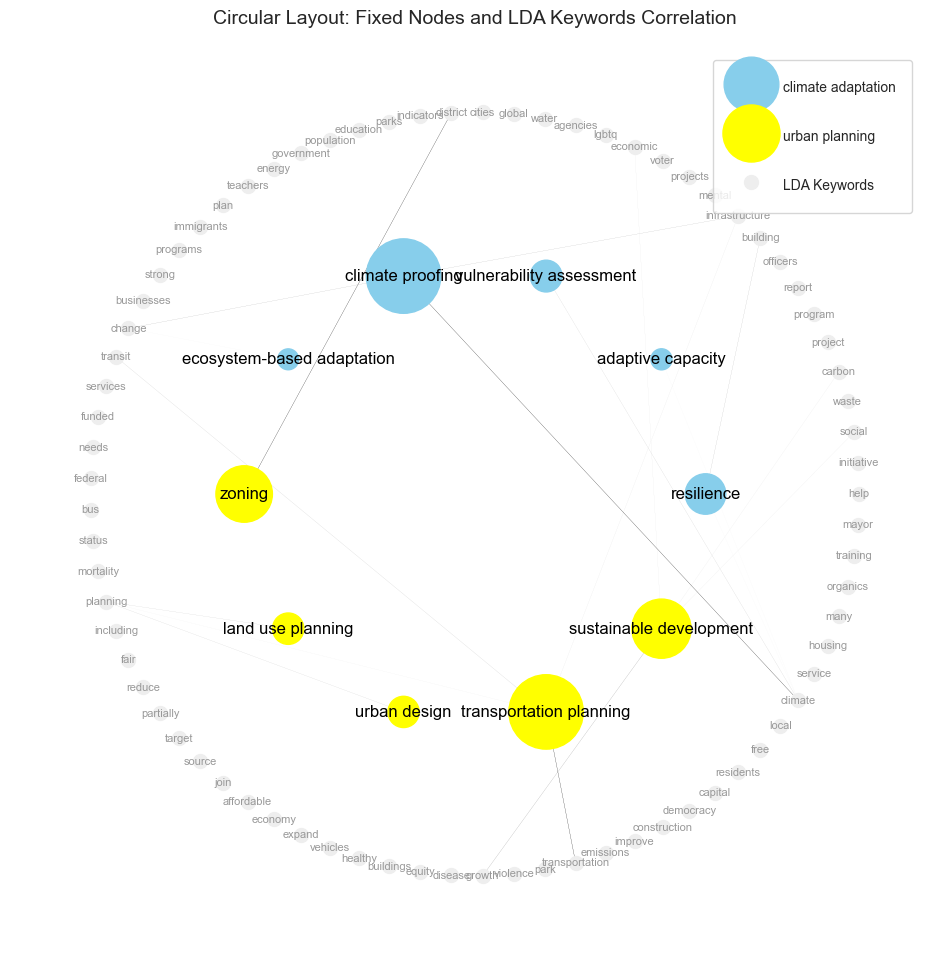

In [12]:
# 构建图
G = nx.Graph()

# 构建节点和边
for (fixed_node, lda_keyword), score in correlation_scores.items():
    G.add_node(fixed_node, type='fixed')  # 蓝色固定节点
    G.add_node(lda_keyword, type='lda_word')  # 绿色关键词节点
    G.add_edge(fixed_node, lda_keyword, weight=score)

#########################
# 定义自定义顺序列表
custom_order = ['resilience','adaptive capacity','vulnerability assessment','climate proofing','ecosystem-based adaptation','zoning','land use planning','urban design','transportation planning','sustainable development']
#########################

radius_inner = 1.5  # 控制内圈的半径
radius_outer = 2.5  # 控制外圈的半径（可以根据需要调整）

# 绘制布局：固定节点在内圈，关键词节点在外圈
# 获取类型为 'fixed' 的节点
fixed_node_list = [node for node, attr in G.nodes(data=True) if attr['type'] == 'fixed']
# 将节点按照 custom_order 中的顺序排列，如果节点不在 custom_order 中，保持原有顺序
fixed_node_list.sort(key=lambda x: custom_order.index(x) if x in custom_order else float('inf'))
lda_node_list = [node for node, attr in G.nodes(data=True) if attr['type'] == 'lda_word']

# 调整 shell_layout，将内圈的半径设置为 1.5，外圈设置为 2.5
# 使用 shell_layout 来布局节点
shell_layout = [fixed_node_list, lda_node_list]  # 内圈：固定节点，外圈：关键词节点
pos = nx.shell_layout(G, nlist=shell_layout)  # 传递两个列表，不需要嵌套

# 调整内圈半径
for node in fixed_node_list:
    pos[node] = (pos[node][0] * radius_inner, pos[node][1] * radius_inner)

#######################
# 设置旋转角度
rotation_angle = 18 * np.pi / 180  # 36度转换为弧度
# 旋转内圈节点
for node in fixed_node_list:
    x, y = pos[node]  # 获取原始坐标
    r = np.sqrt(x**2 + y**2)  # 计算半径
    theta = np.arctan2(y, x)  # 计算原始角度
    theta += rotation_angle  # 增加36度的旋转
    # 将新的极坐标转换为笛卡尔坐标
    pos[node] = (r * np.cos(theta), r * np.sin(theta))
#######################
# 手动设置节点的位置：内圈的节点（fixed_node_list）和外圈的节点（lda_node_list）
pos = {}

# 按照自定义顺序放置固定节点在内圈
for i, node in enumerate(fixed_node_list):
    angle = 2 * np.pi * i / len(fixed_node_list)
    pos[node] = (radius_inner * np.cos(angle), radius_inner * np.sin(angle))

# 将 LDA 关键词节点放置在外圈
for i, node in enumerate(lda_node_list):
    angle = 2 * np.pi * i / len(lda_node_list)
    pos[node] = (radius_outer * np.cos(angle), radius_outer * np.sin(angle))

# 绘制图形
plt.figure(figsize=(12, 12), facecolor="#ffffff")
# 去掉坐标轴
plt.axis('off')  # 关闭坐标轴
k=10000
# 绘制前五个固定节点（蓝色，中心较大）
nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=list(fixed_nodes_list.keys())[:5],  # 前五个节点
    node_color="skyblue",
    node_size=[size * k for size in sizes[:5]],  # 计算前五个节点的大小
    label="climate adaptation"
)

# 绘制剩余的固定节点（黄色）
nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=list(fixed_nodes_list.keys())[5:],  # 剩余节点
    node_color="yellow",
    node_size=[size * k for size in sizes[5:]],  # 计算剩余节点的大小
    label="urban planning"
)
print(sizes)

nx.draw_networkx_labels(G, pos, labels={node: node for node in fixed_node_list}, font_size=12)

# 绘制关键词节点（绿色，外围较小）
nx.draw_networkx_nodes(
    G, pos, nodelist=lda_node_list,node_color="#EEEEEE", node_size=100, label="LDA Keywords"
)
nx.draw_networkx_labels(G, pos, labels={node: node for node in lda_node_list}, font_size=8,font_color="#999999")

# 绘制边
edges = G.edges(data=True)
weights = [d['weight'] for _, _, d in edges]
nx.draw_networkx_edges(G, pos, edgelist=edges, edge_color=weights, edge_cmap=plt.cm.Greys,edge_vmin=0, edge_vmax=max(weights) * 0.5, width=[w for w in weights])

# 添加标题
plt.title("Circular Layout: Fixed Nodes and LDA Keywords Correlation", fontsize=14)
plt.legend(scatterpoints=1, loc="upper right",
           labelspacing=2,
           handlelength=3,
           borderaxespad=2,
           handleheight=2,
           borderpad=1.2)
plt.show()


In [13]:
# 查看结果
for node, total_score in node_total_scores.items():
    print(f"{node}: {total_score:.4f}")

resilience: 0.0849
adaptive capacity: 0.0230
vulnerability assessment: 0.0523
climate proofing: 0.2875
ecosystem-based adaptation: 0.0226
zoning: 0.1655
land use planning: 0.0511
urban design: 0.0506
transportation planning: 0.2871
sustainable development: 0.1817


In [14]:
topic_labels

['Topic 0: housing, economic, growth, education, economy, businesses, residents, population, services, many',
 'Topic 1: projects, parks, project, capital, planning, source, park, bus, improve, construction',
 'Topic 2: residents, mayor, report, government, help, immigrants, violence, voter, federal, democracy',
 'Topic 3: fair, strong, building, infrastructure, climate, healthy, education, needs, equity, democracy',
 'Topic 4: climate, emissions, reduce, change, transportation, vehicles, energy, infrastructure, carbon, transit',
 'Topic 5: climate, programs, cities, global, local, training, officers, help, program, education',
 'Topic 6: waste, buildings, emissions, energy, carbon, including, climate, expand, organics, reduce',
 'Topic 7: service, mayor, program, services, social, projects, free, mental, join, expand',
 'Topic 8: funded, housing, indicators, partially, district, status, initiative, affordable, plan, target',
 'Topic 9: mortality, equity, climate, program, teachers, ag

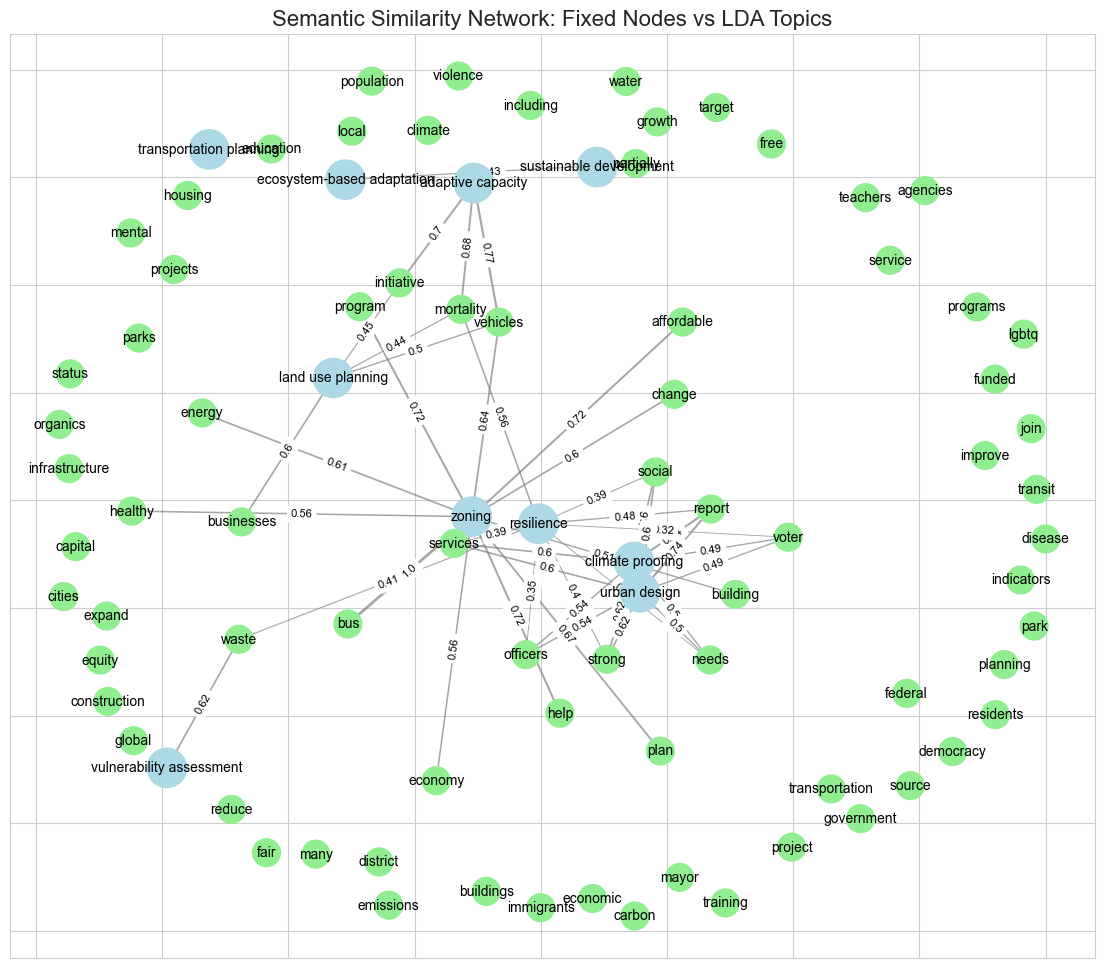

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx
import matplotlib.pyplot as plt

# 定义固定节点和 LDA 主题节点
fixed_nodes = {
    'adaptive capacity': ['adaptive', 'adaptation', 'adapt', 'adjustment ability', 'adaptation capacity', 'flexibility', 'resilience', 'adaptation', 'coping ability', 'adaptive response', 'climate resilience', 'adaptive management', 'adaptation strategies', 'capacity to adapt', 'system adaptability'],
    'climate proofing': ['climate proofing', 'climate resilience', 'climate adaptation', 'climate change adaptation', 'climate resilience strategies', 'climate protection', 'climate-smart infrastructure', 'resilient infrastructure', 'climate adaptation measures', 'climate change mitigation'],
    'vulnerability assessment': ['vulnerability', 'vulnerable', 'vulnerability analysis', 'risk assessment', 'impact assessment', 'climate risk evaluation', 'climate vulnerability', 'threat analysis', 'hazard assessment', 'vulnerability mapping', 'climate risk analysis', 'resilience assessment'],
    'ecosystem-based adaptation': ['ecosystem adaptative', 'ecosystem resilience', 'ecosystem change', 'ecosystem', 'ecological adaptation', 'ecosystem response', 'ecological resilience', 'ecosystem transformation', 'environmental adaptation', 'ecosystem sustainability', 'ecosystem-based adaptation', 'ecosystem management'],
    'resilience': ['resilience', 'resilient', 'adaptive capacity', 'toughness', 'durability', 'robustness', 'resiliency', 'recovery ability', 'strength', 'sustainability', 'robust system', 'climate resilience', 'disaster resilience', 'resilient systems', 'adaptive resilience', 'resilience building'],
    'transportation planning': ['transportation planning', 'public transport', 'transportation', 'transport', 'public transit', 'transport infrastructure', 'transportation systems', 'urban transport'],
    'zoning': ['zoning', 'land use regulation', 'urban zoning', 'zoning laws', 'land use planning', 'urban land use', 'land zoning', 'zoning ordinances', 'zoning policies', 'land use regulations', 'zoning codes', 'land use management', 'urban zoning policies', 'spatial zoning'],
    'urban design': ['urban design', 'city planning', 'urban development', 'city design', 'urban form', 'urban planning', 'built environment', 'urban renewal', 'city layout', 'urban architecture', 'urban planning design', 'sustainable urban design', 'urban space design', 'city landscape design'],
    'sustainable development': ['sustainable development', 'sustainability', 'green development', 'sustainable growth', 'eco-friendly development', 'environmental sustainability', 'eco-development', 'green growth', 'environmentally sustainable development', 'sustainable urban development', 'low-carbon development', 'social sustainability', 'economic sustainability', 'sustainability initiatives'],
    'land use planning': ['land use', 'urban land', 'land development', 'land management', 'land allocation', 'urban land use', 'spatial planning', 'land use policies', 'land planning', 'territorial planning', 'land use zoning', 'land use strategy', 'urban land management', 'land use regulations', 'land use planning policies']
}

# 解析主题标签
lda_topics = [
    'adaptive capacity and resilience in response to climate change and environmental stress',
    'climate proofing and resilient infrastructure to mitigate climate risks',
    'vulnerability assessment and risk mapping for disaster preparedness',
    'ecosystem-based adaptation focusing on ecological resilience and sustainability',
    'building sustainability and adaptive capacity for resilient communities',
    'transportation planning and sustainable transit systems for urban mobility',
    'urban zoning and spatial policies for effective land use management',
    'urban design and development strategies for livable cities',
    'sustainable development and green initiatives for ecological and social balance',
    'land use planning for integrated urban and rural growth'
]


# 合并所有节点文本
all_texts = []

# 将 fixed_nodes 的关键词添加到 all_texts
for node in fixed_nodes.values():
    all_texts.extend(node)

# 将 lda_topics 的标签添加到 all_texts
all_texts.extend(lda_topics)

# 使用 TF-IDF 计算相似性
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(all_texts)
similarity_matrix = cosine_similarity(tfidf_matrix)

# 创建网络图
G = nx.Graph()

# 添加固定节点
for node in fixed_nodes:
    G.add_node(node, type="fixed", color="lightblue", size=800)

# 添加主题节点
for topic in word_nodes:
    G.add_node(topic, type="topic", color="lightgreen", size=400)

# 添加边（相似度阈值 > 0.2）
threshold = 0.2
for i, fixed_node in enumerate(fixed_nodes):
    for j, word_node in enumerate(word_nodes, len(fixed_nodes)):
        similarity = similarity_matrix[i, j]
        if similarity > threshold:  # 设置相似度阈值
            G.add_edge(fixed_node, word_node, weight=round(similarity, 2))

# 提取节点颜色和大小
node_colors = [nx.get_node_attributes(G, 'color')[node] for node in G.nodes]
node_sizes = [nx.get_node_attributes(G, 'size')[node] for node in G.nodes]

# 绘制网络图
plt.figure(figsize=(14, 12))
pos = nx.spring_layout(G, k=0.5, seed=42)  # 固定布局以便可重复生成

# 绘制节点
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes)

# 绘制标签
nx.draw_networkx_labels(G, pos, font_size=10)

# 绘制边
edges = G.edges(data=True)
weights = [d['weight'] for _, _, d in edges]
nx.draw_networkx_edges(
    G, pos, edgelist=edges, edge_color="gray", alpha=0.7, width=[w * 2 for w in weights]
)

# 添加边的权重标签
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(
    G, pos, edge_labels={k: f"{v}" for k, v in edge_labels.items()},
    font_size=8, label_pos=0.5
)

plt.title("Semantic Similarity Network: Fixed Nodes vs LDA Topics", fontsize=16)
plt.show()


In [16]:
lda_model.save('lda_model')

In [17]:
from gensim.models import LdaModel
lda_model = LdaModel.load('lda_model')


In [18]:
for idx, doc in enumerate(corpus):
    topic_probs = lda_model.get_document_topics(doc, minimum_probability=0.1)
    print(f"Document {idx}: {topic_probs}")


Document 0: [(3, 0.99476683)]
Document 1: [(7, 0.9639944)]
Document 2: [(1, 0.9499574)]
Document 3: [(4, 0.11245614), (6, 0.8844047)]
Document 4: [(2, 0.45214984), (3, 0.4398896)]
Document 5: [(0, 0.26336172), (3, 0.17786394), (4, 0.27470192), (5, 0.28135473)]
Document 6: [(0, 0.5034656), (1, 0.14814043), (3, 0.33282408)]
Document 7: [(0, 0.15755545), (2, 0.304015), (3, 0.40887645), (4, 0.12517022)]
Document 8: [(1, 0.6601086), (3, 0.30786356)]
Document 9: [(1, 0.69980806)]
Document 10: [(0, 0.31095013), (2, 0.21502014), (4, 0.42359194)]
Document 11: [(0, 0.4581224), (3, 0.2163942), (4, 0.32161206)]
Document 12: [(0, 0.45249444), (4, 0.24990608), (6, 0.29488376)]
Document 13: [(4, 0.48345065), (7, 0.4784197)]
Document 14: [(0, 0.3141762), (3, 0.25794148), (5, 0.33503318)]
Document 15: [(9, 0.9356878)]
Document 16: [(3, 0.9921716)]
Document 17: [(3, 0.99560845)]
Document 18: [(3, 0.95908755)]
Document 19: [(3, 0.99399924)]
Document 20: [(0, 0.5499392)]
Document 21: [(0, 0.46281388), (2,

In [19]:
import numpy as np

# 假设 corpus 是一个文档列表，lda_model 是训练好的 LDA 模型
total_documents = len(corpus)
topic_frequencies = np.zeros(lda_model.num_topics)

# 遍历每个文档
for doc in corpus:
    # 获取该文档在每个主题上的概率分布
    topic_probs = lda_model.get_document_topics(doc, minimum_probability=0.1)

    # 累加每个主题的概率值
    for topic_id, prob in topic_probs:
        topic_frequencies[topic_id] += prob

# 计算每个主题的平均概率，即出现频率
topic_frequencies /= total_documents

# 输出各个主题的频率
for topic_id, frequency in enumerate(topic_frequencies):
    print(f"Topic {topic_id}: Frequency = {frequency:.4f}")


Topic 0: Frequency = 0.1820
Topic 1: Frequency = 0.0969
Topic 2: Frequency = 0.0626
Topic 3: Frequency = 0.1561
Topic 4: Frequency = 0.1278
Topic 5: Frequency = 0.0525
Topic 6: Frequency = 0.0660
Topic 7: Frequency = 0.1022
Topic 8: Frequency = 0.0764
Topic 9: Frequency = 0.0432


[[5.8147049e-04 5.8144418e-04 5.8146822e-04 ... 5.8154832e-04
  5.8145088e-04 5.8144325e-04]
 [4.0005916e-03 4.0005804e-03 4.0006414e-03 ... 9.6399438e-01
  4.0006288e-03 4.0005301e-03]
 [5.5622295e-03 9.4995695e-01 5.5602943e-03 ... 5.5593951e-03
  5.5603771e-03 5.5591646e-03]
 ...
 [6.8547839e-04 6.8553729e-04 6.8535819e-04 ... 1.8809137e-01
  5.3672808e-01 6.8553363e-04]
 [4.6974589e-04 4.6972581e-04 4.6971638e-04 ... 1.7319182e-01
  4.6973326e-04 8.1109780e-01]
 [4.1670022e-03 4.1668690e-03 4.1670804e-03 ... 9.6249610e-01
  4.1669076e-03 4.1668704e-03]]


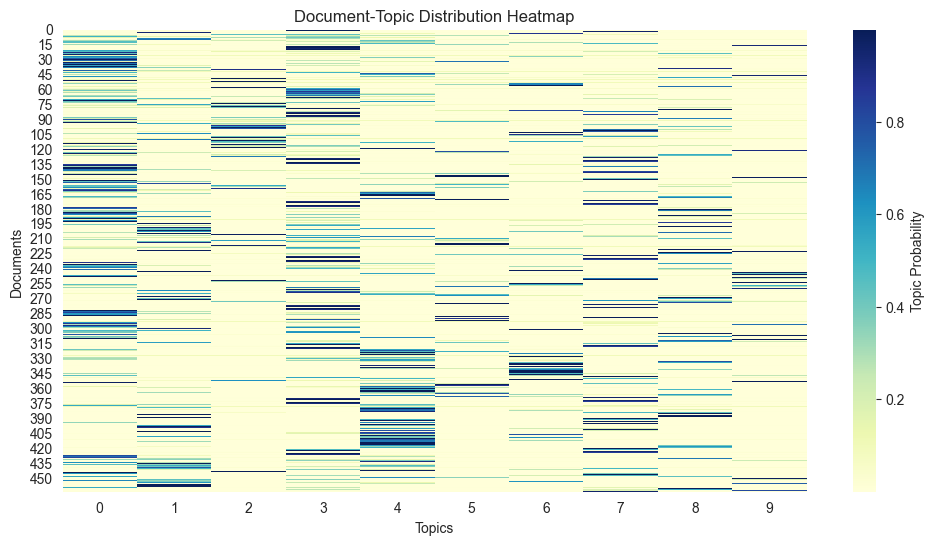

In [20]:
# 获取主题-词分布
topic_word_distributions = lda_model.get_topics()

# 获取文档-主题分布
document_topic_distributions = [
    lda_model.get_document_topics(doc, minimum_probability=0.0) for doc in corpus
]
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 转换为矩阵形式
doc_topic_matrix = np.array([
    [topic_prob[1] for topic_prob in sorted(doc, key=lambda x: x[0])]
    for doc in document_topic_distributions
])
print(doc_topic_matrix)
# 绘制热力图
plt.figure(figsize=(12, 6))
sns.heatmap(doc_topic_matrix, cmap="YlGnBu", cbar_kws={'label': 'Topic Probability'})
plt.xlabel("Topics")
plt.ylabel("Documents")
plt.title("Document-Topic Distribution Heatmap")
plt.show()


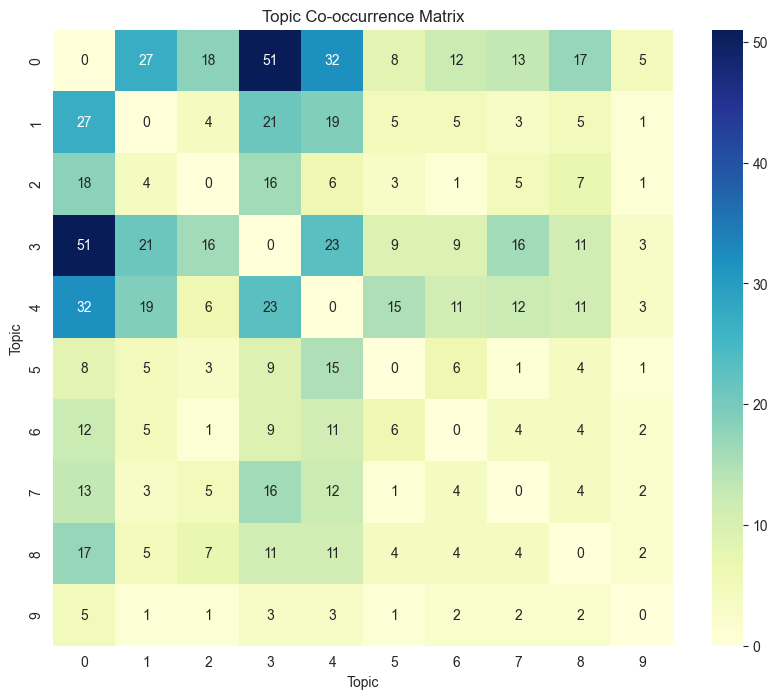

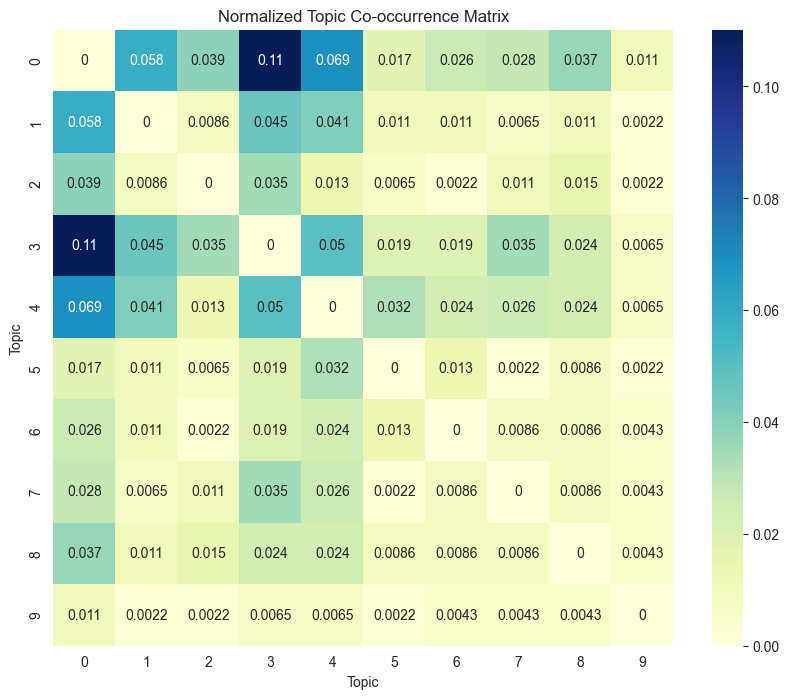

In [21]:
import numpy as np

# 假设doc_topic_matrix是文档-主题分布矩阵
# doc_topic_matrix.shape = (num_docs, num_topics)

# 设置一个阈值，表示哪些主题的权重视为“存在”该主题
threshold = 0.1  # 可根据需要调整阈值

# 计算主题共现矩阵
num_topics = doc_topic_matrix.shape[1]
cooccurrence_matrix = np.zeros((num_topics, num_topics))

# 遍历每个文档
for doc in doc_topic_matrix:
    # 获取权重大于阈值的主题索引
    active_topics = np.where(doc > threshold)[0]

    # 计算这些主题的共现
    for i in range(len(active_topics)):
        for j in range(i + 1, len(active_topics)):
            cooccurrence_matrix[active_topics[i], active_topics[j]] += 1
            cooccurrence_matrix[active_topics[j], active_topics[i]] += 1

# 可视化共现矩阵
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(cooccurrence_matrix, annot=True, cmap="YlGnBu", xticklabels=range(num_topics), yticklabels=range(num_topics))
plt.title("Topic Co-occurrence Matrix")
plt.xlabel("Topic")
plt.ylabel("Topic")
plt.show()

# 如果需要归一化共现频率，可以除以文档总数
cooccurrence_matrix_normalized = cooccurrence_matrix / doc_topic_matrix.shape[0]

# 可视化归一化后的共现矩阵
plt.figure(figsize=(10, 8))
sns.heatmap(cooccurrence_matrix_normalized, annot=True, cmap="YlGnBu", xticklabels=range(num_topics), yticklabels=range(num_topics))
plt.title("Normalized Topic Co-occurrence Matrix")
plt.xlabel("Topic")
plt.ylabel("Topic")
plt.show()


Subnodes Co-occurrence Matrix:
[[1.29581742e-04 2.37571534e-04 1.29579137e-04 ... 1.51182569e-04
  6.47908711e-05 1.94370008e-04]
 [2.37571534e-04 0.00000000e+00 8.63894451e-05 ... 8.63911392e-05
  8.63917263e-05 2.37569253e-04]
 [1.29579137e-04 8.63894451e-05 0.00000000e+00 ... 8.63882247e-05
  2.15972029e-05 1.07981934e-04]
 ...
 [1.51182569e-04 8.63911392e-05 8.63882247e-05 ... 0.00000000e+00
  1.29585759e-04 1.07985035e-04]
 [6.47908711e-05 8.63917263e-05 2.15972029e-05 ... 1.29585759e-04
  0.00000000e+00 8.63880741e-05]
 [1.94370008e-04 2.37569253e-04 1.07981934e-04 ... 1.07985035e-04
  8.63880741e-05 2.15963868e-04]]


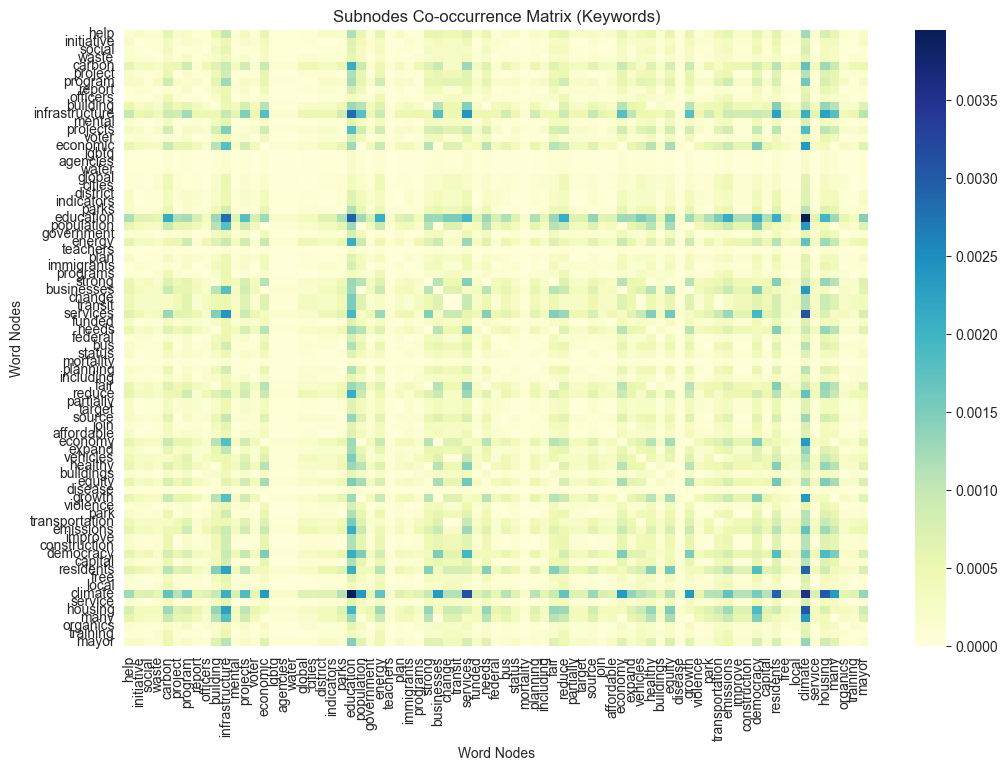

In [22]:
# 初始化子节点共现矩阵
subnodes_cooccurrence_matrix = np.zeros((len(word_nodes), len(word_nodes)))

# 计算子节点的共现矩阵
for i in range(len(word_nodes)):
    for j in range(len(word_nodes)):
        # 遍历所有主题组合，累加加权共现值
        for k in range(len(topic_nodes)):
            for l in range(len(topic_nodes)):
                subnodes_cooccurrence_matrix[i, j] += (
                    cooccurrence_matrix_normalized[k, l] * weight_matrix[k, i] * weight_matrix[l, j]
                )

# 输出子节点共现矩阵
print("Subnodes Co-occurrence Matrix:")
print(subnodes_cooccurrence_matrix)

# 可视化子节点共现矩阵
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(subnodes_cooccurrence_matrix, cmap="YlGnBu", xticklabels=word_nodes, yticklabels=word_nodes, annot=False)
plt.title("Subnodes Co-occurrence Matrix (Keywords)")
plt.xlabel("Word Nodes")
plt.ylabel("Word Nodes")
plt.show()


In [23]:
correlation_scores

{('resilience', 'help'): 0,
 ('resilience', 'initiative'): 0,
 ('resilience', 'social'): 0.0,
 ('resilience', 'waste'): 0,
 ('resilience', 'carbon'): 0.0,
 ('resilience', 'project'): 0,
 ('resilience', 'program'): 0,
 ('resilience', 'report'): 0,
 ('resilience', 'officers'): 0,
 ('resilience', 'building'): 0.05905394190516695,
 ('resilience', 'infrastructure'): 0.0,
 ('resilience', 'mental'): 0,
 ('resilience', 'projects'): 0,
 ('resilience', 'voter'): 0,
 ('resilience', 'economic'): 0.0,
 ('resilience', 'lgbtq'): 0,
 ('resilience', 'agencies'): 0,
 ('resilience', 'water'): 0,
 ('resilience', 'global'): 0,
 ('resilience', 'cities'): 0,
 ('resilience', 'district'): 0.0,
 ('resilience', 'indicators'): 0,
 ('resilience', 'parks'): 0,
 ('resilience', 'education'): 0,
 ('resilience', 'population'): 0,
 ('resilience', 'government'): 0,
 ('resilience', 'energy'): 0,
 ('resilience', 'teachers'): 0,
 ('resilience', 'plan'): 0,
 ('resilience', 'immigrants'): 0,
 ('resilience', 'programs'): 0,
 (

In [24]:
node_total_scores

{'resilience': 0.08487371532890214,
 'adaptive capacity': 0.023013333890336916,
 'vulnerability assessment': 0.052293841218586934,
 'climate proofing': 0.28745105794133374,
 'ecosystem-based adaptation': 0.02264978504031477,
 'zoning': 0.1654567108292678,
 'land use planning': 0.051060641100720686,
 'urban design': 0.050620253760241755,
 'transportation planning': 0.2871329142553589,
 'sustainable development': 0.18169056675051282}

In [25]:
# Ensure values are rounded and formatted to 4 decimal places
V1_rounded = {key: format(value, '.4f') for key, value in node_total_scores.items()}

print(V1_rounded)

{'resilience': '0.0849', 'adaptive capacity': '0.0230', 'vulnerability assessment': '0.0523', 'climate proofing': '0.2875', 'ecosystem-based adaptation': '0.0226', 'zoning': '0.1655', 'land use planning': '0.0511', 'urban design': '0.0506', 'transportation planning': '0.2871', 'sustainable development': '0.1817'}


In [26]:
custom_order

['resilience',
 'adaptive capacity',
 'vulnerability assessment',
 'climate proofing',
 'ecosystem-based adaptation',
 'zoning',
 'land use planning',
 'urban design',
 'transportation planning',
 'sustainable development']

In [27]:
# 1. 初始化 topic_word_weights 字典
topic_word_weights = {topic: {} for topic in custom_order}

# 2. 填充 topic_word_weights 字典
for (topic, word), weight in correlation_scores.items():
    if topic in topic_word_weights:
        topic_word_weights[topic][word] = weight

# 打印结果
print(topic_word_weights)

{'resilience': {'help': 0, 'initiative': 0, 'social': 0.0, 'waste': 0, 'carbon': 0.0, 'project': 0, 'program': 0, 'report': 0, 'officers': 0, 'building': 0.05905394190516695, 'infrastructure': 0.0, 'mental': 0, 'projects': 0, 'voter': 0, 'economic': 0.0, 'lgbtq': 0, 'agencies': 0, 'water': 0, 'global': 0, 'cities': 0, 'district': 0.0, 'indicators': 0, 'parks': 0, 'education': 0, 'population': 0, 'government': 0, 'energy': 0, 'teachers': 0, 'plan': 0, 'immigrants': 0, 'programs': 0, 'strong': 0, 'businesses': 0, 'change': 0.0, 'transit': 0.0, 'services': 0, 'funded': 0, 'needs': 0, 'federal': 0, 'bus': 0, 'status': 0, 'mortality': 0, 'planning': 0.0, 'including': 0, 'fair': 0, 'reduce': 0, 'partially': 0, 'target': 0, 'source': 0, 'join': 0, 'affordable': 0, 'economy': 0, 'expand': 0, 'vehicles': 0, 'healthy': 0, 'buildings': 0, 'equity': 0, 'disease': 0, 'growth': 0.0, 'violence': 0, 'park': 0, 'transportation': 0.0, 'emissions': 0, 'improve': 0, 'construction': 0, 'democracy': 0, 'cap

Weighted Topic Co-occurrence via Shared Word Nodes

In [28]:
# 初始化主题节点之间的间接共现频率字典
topic_cooccurrence = {topic1: {topic2: 0 for topic2 in topic_word_weights.keys()}
                      for topic1 in topic_word_weights.keys()}

# 遍历所有主题对
for topic1 in topic_word_weights.keys():
    for topic2 in topic_word_weights.keys():
        if topic1 == topic2:
            continue  # 跳过自己与自己的共现

        # 遍历 topic1 和 topic2 关联的词节点
        for word1, weight1 in topic_word_weights[topic1].items():
            for word2, weight2 in topic_word_weights[topic2].items():
                # 获取词节点间的共现权重
                if word1 in word_nodes and word2 in word_nodes:
                    idx1 = word_nodes.index(word1)
                    idx2 = word_nodes.index(word2)
                    word_cooccurrence_weight = subnodes_cooccurrence_matrix[idx1, idx2]

                    # 累加到主题之间的共现权重
                    topic_cooccurrence[topic1][topic2] += weight1 * weight2 * word_cooccurrence_weight

# 输出结果
print("Topic Co-occurrence Weights:")
for topic1, connections in topic_cooccurrence.items():
    for topic2, weight in connections.items():
        if weight > 0:
            print(f"{topic1} <-> {topic2}: {weight:.10f}")


Topic Co-occurrence Weights:
resilience <-> adaptive capacity: 0.0000033962
resilience <-> vulnerability assessment: 0.0000077172
resilience <-> climate proofing: 0.0000330500
resilience <-> ecosystem-based adaptation: 0.0000013212
resilience <-> zoning: 0.0000052739
resilience <-> land use planning: 0.0000028197
resilience <-> urban design: 0.0000027954
resilience <-> transportation planning: 0.0000176206
resilience <-> sustainable development: 0.0000182123
adaptive capacity <-> resilience: 0.0000033962
adaptive capacity <-> vulnerability assessment: 0.0000042627
adaptive capacity <-> climate proofing: 0.0000179857
adaptive capacity <-> ecosystem-based adaptation: 0.0000005854
adaptive capacity <-> zoning: 0.0000026316
adaptive capacity <-> land use planning: 0.0000012943
adaptive capacity <-> urban design: 0.0000012831
adaptive capacity <-> transportation planning: 0.0000082663
adaptive capacity <-> sustainable development: 0.0000079292
vulnerability assessment <-> resilience: 0.0000

In [29]:
topic_cooccurrence

{'resilience': {'resilience': 0,
  'adaptive capacity': 3.3961688441099024e-06,
  'vulnerability assessment': 7.717209298387104e-06,
  'climate proofing': 3.305003992618672e-05,
  'ecosystem-based adaptation': 1.3212181562230614e-06,
  'zoning': 5.273927376171975e-06,
  'land use planning': 2.819734896699115e-06,
  'urban design': 2.7954152734972937e-06,
  'transportation planning': 1.7620610603119733e-05,
  'sustainable development': 1.8212253575007693e-05},
 'adaptive capacity': {'resilience': 3.3961688441099024e-06,
  'adaptive capacity': 0,
  'vulnerability assessment': 4.262682565275881e-06,
  'climate proofing': 1.7985713865654508e-05,
  'ecosystem-based adaptation': 5.854001510281365e-07,
  'zoning': 2.6316407365253124e-06,
  'land use planning': 1.294299821881626e-06,
  'urban design': 1.2831367568661191e-06,
  'transportation planning': 8.266326520541172e-06,
  'sustainable development': 7.92919859535663e-06},
 'vulnerability assessment': {'resilience': 7.717209298387104e-06,


[0.08487371532890214, 0.023013333890336916, 0.052293841218586934, 0.28745105794133374, 0.02264978504031477, 0.1654567108292678, 0.051060641100720686, 0.050620253760241755, 0.2871329142553589, 0.18169056675051282]


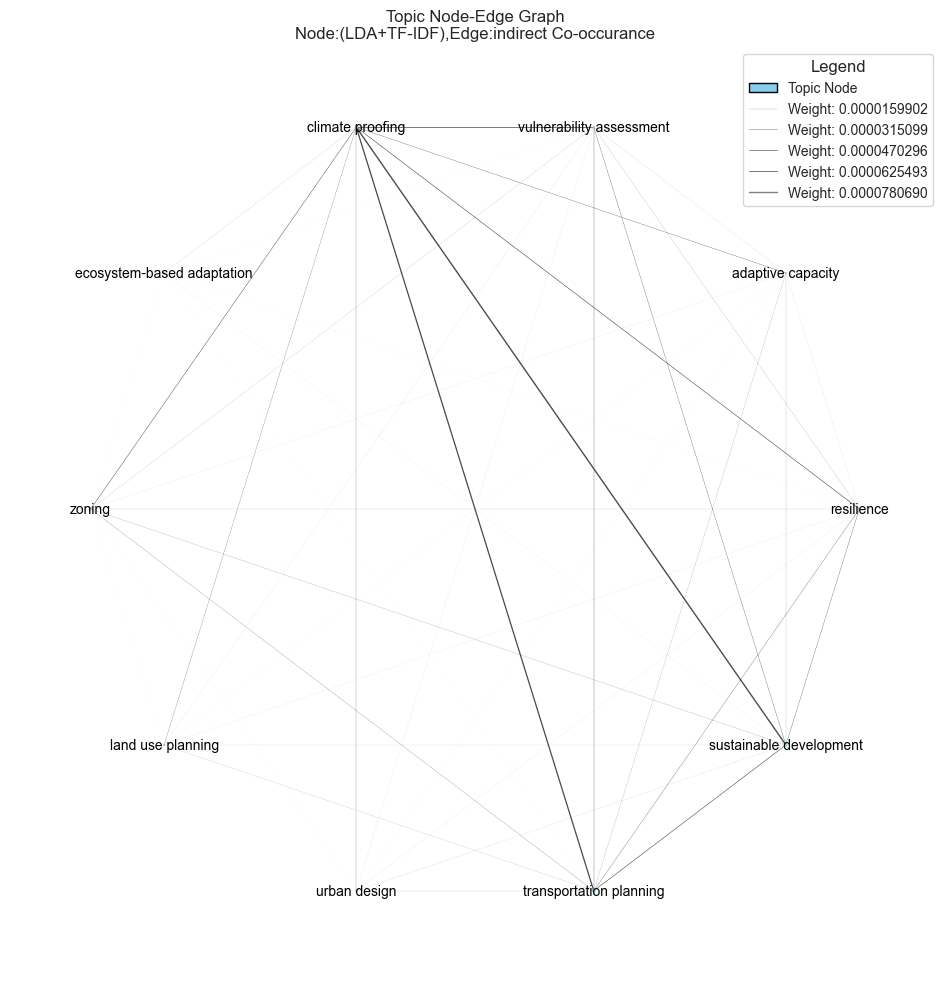

In [30]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# 构建图
G1 = nx.Graph()  # 如果需要有向图，改为 nx.DiGraph()

# 添加节点
for topic in topic_cooccurrence.keys():
    G1.add_node(topic)

# 添加边及权重
for topic1, connections in topic_cooccurrence.items():
    for topic2, weight2 in connections.items():
        if weight2 > 0:  # 只添加有权重的边
            G1.add_edge(topic1, topic2, weight=weight2)

# 使用圆形布局并添加扰动
pos = nx.circular_layout(G1)
np.random.seed(42)  # 固定随机种子以复现

# 提取边的权重
edges1 = G1.edges(data=True)
weights1 = [data['weight'] for _, _, data in edges1]

# 归一化权重到 1 到 10
min_weight, max_weight = min(weights1), max(weights1)
normalized_weights = [
    0 + (weight1 - min_weight) / (max_weight - min_weight) * 1 for weight1 in weights1
]


# 生成用于图例的示例边权重
example_weights = np.linspace(min_weight, max_weight, 6)  # 生成五个等间隔的权重
example_widths = [
    0 + (w - min_weight) / (max_weight - min_weight) * 1 for w in example_weights
]
# 移除第一个权重和对应的宽度
example_weights = example_weights[1:]
example_widths = example_widths[1:]

# 绘制图
plt.figure(figsize=(12, 12))

# 绘制固定节点（蓝色，中心较大）
nx.draw_networkx_nodes(
    G1,
    pos,
    nodelist=fixed_nodes_list,
    node_color="skyblue",
    node_size=[size * k for size in sizes],  # 将节点大小调大 10 倍
    label="Fixed Nodes"
)
print(sizes)

nx.draw_networkx_edges(G1, pos, width=normalized_weights, alpha=0.7)
nx.draw_networkx_labels(G1, pos, font_size=10, font_color='black')

# 添加图例
legend_elements = [
    Patch(facecolor='skyblue', edgecolor='black', label='Topic Node')
]

# 添加边权重示例
for w, width in zip(example_weights, example_widths):
    legend_elements.append(
        Line2D(
            [0], [0],
            color='gray',
            lw=width,
            label=f"Weight: {w:.10f}"
        )
    )

plt.legend(
    handles=legend_elements,
    loc="upper right",
    fontsize=10,
    title="Legend",
    title_fontsize=12,
    frameon=True,
)

# 显示图
plt.title("Topic Node-Edge Graph\nNode:(LDA+TF-IDF),Edge:indirect Co-occurance")
plt.axis('off')
plt.show()


sizes:[0.08487371532890214, 0.023013333890336916, 0.052293841218586934, 0.28745105794133374, 0.02264978504031477, 0.1654567108292678, 0.051060641100720686, 0.050620253760241755, 0.2871329142553589, 0.18169056675051282]
4.704735812602597e-07
normalized_weights[0.037702962523175926, 0.09338751326140263, 0.4198476117870425, 0.01096340799190957, 0.06190133357736201, 0.030274551303359768, 0.029961148245358796, 0.22101104705371713, 0.22863545451660014, 0.04886958495640834, 0.22571607385511758, 0.0014810401506597742, 0.027850612227437774, 0.010616515762992693, 0.010472659146321861, 0.10046389825289355, 0.09611938510753999, 0.5206149561801967, 0.01107942760086776, 0.07099974256940551, 0.03183822393190283, 0.031511334524819294, 0.23600094004342476, 0.22612878150795165, 0.05708573166655078, 0.3306443587758947, 0.16507869813688975, 0.16360263753229737, 0.9219141912415576, 1.0, 0.00541053108477912, 5.274631661118547e-05, 0.0, 0.0032453297778566926, 0.021197803700490882, 0.005693885087987874, 0.005

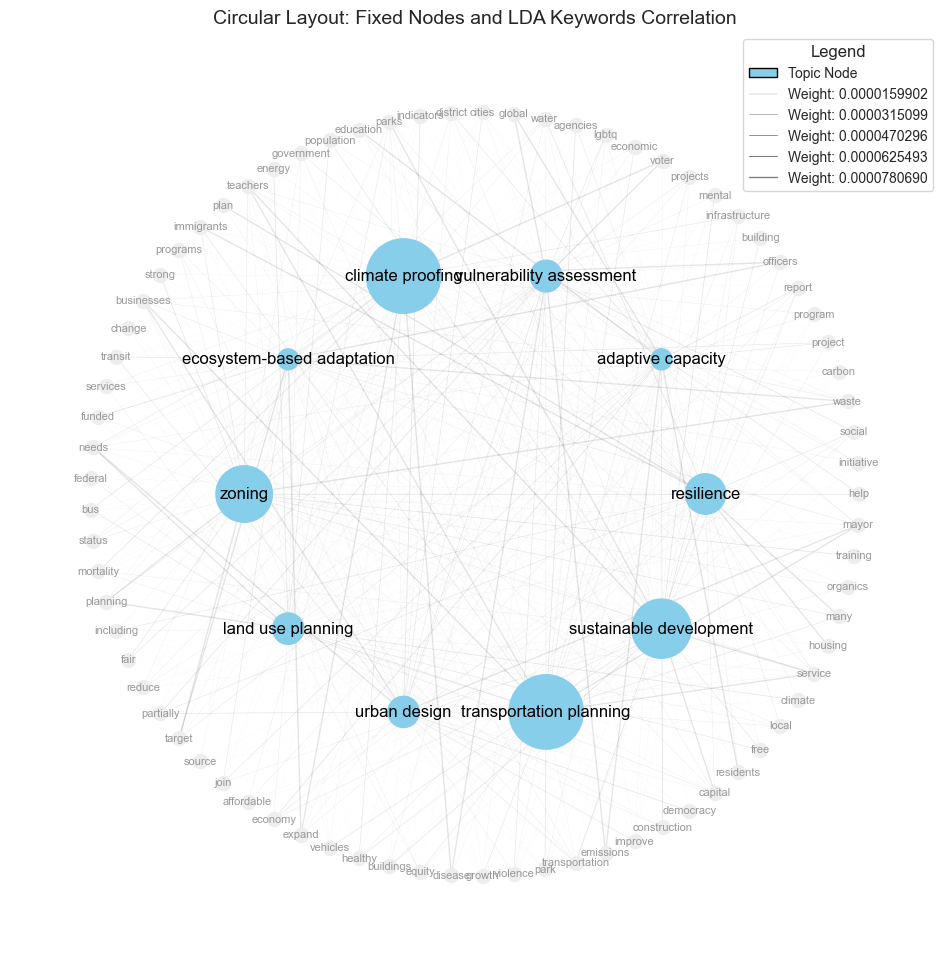

In [31]:
# 构建图
G = nx.Graph()
# 手动设置节点的位置：内圈的节点（fixed_node_list）和外圈的节点（lda_node_list）
pos = {}

# 构建节点和边
for (fixed_node, lda_keyword), score in correlation_scores.items():
    G.add_node(fixed_node, type='fixed')  # 蓝色固定节点
    G.add_node(lda_keyword, type='lda_word')  # 绿色关键词节点
    G.add_edge(fixed_node, lda_keyword, weight=score)

# 添加边及权重
for topic1, connections in topic_cooccurrence.items():
    for topic2, weight2 in connections.items():
        if weight2 > 0:  # 只添加有权重的边
            G.add_edge(topic1, topic2, weight=weight2)
# 提取边的权重
edges = G.edges(data=True)
weights = [data['weight'] for _, _, data in edges]
#########################
# 定义自定义顺序列表
custom_order = ['resilience','adaptive capacity','vulnerability assessment','climate proofing','ecosystem-based adaptation','zoning','land use planning','urban design','transportation planning','sustainable development']
#########################

radius_inner = 1.5  # 控制内圈的半径
radius_outer = 2.5  # 控制外圈的半径（可以根据需要调整）

# 绘制布局：固定节点在内圈，关键词节点在外圈
# 获取类型为 'fixed' 的节点
fixed_node_list = [node for node, attr in G.nodes(data=True) if attr['type'] == 'fixed']
# 将节点按照 custom_order 中的顺序排列，如果节点不在 custom_order 中，保持原有顺序
fixed_node_list.sort(key=lambda x: custom_order.index(x) if x in custom_order else float('inf'))
lda_node_list = [node for node, attr in G.nodes(data=True) if attr['type'] == 'lda_word']

# 调整 shell_layout，将内圈的半径设置为 1.5，外圈设置为 2.5
# 使用 shell_layout 来布局节点
shell_layout = [fixed_node_list, lda_node_list]  # 内圈：固定节点，外圈：关键词节点
pos = nx.shell_layout(G, nlist=shell_layout)  # 传递两个列表，不需要嵌套

# 调整内圈半径
for node in fixed_node_list:
    pos[node] = (pos[node][0] * radius_inner, pos[node][1] * radius_inner)

#######################
# 设置旋转角度
rotation_angle = 18 * np.pi / 180  # 36度转换为弧度
# 旋转内圈节点
for node in fixed_node_list:
    x, y = pos[node]  # 获取原始坐标
    r = np.sqrt(x**2 + y**2)  # 计算半径
    theta = np.arctan2(y, x)  # 计算原始角度
    theta += rotation_angle  # 增加36度的旋转
    # 将新的极坐标转换为笛卡尔坐标
    pos[node] = (r * np.cos(theta), r * np.sin(theta))
#######################

# 按照自定义顺序放置固定节点在内圈
for i, node in enumerate(fixed_node_list):
    angle = 2 * np.pi * i / len(fixed_node_list)
    pos[node] = (radius_inner * np.cos(angle), radius_inner * np.sin(angle))

# 将 LDA 关键词节点放置在外圈
for i, node in enumerate(lda_node_list):
    angle = 2 * np.pi * i / len(lda_node_list)
    pos[node] = (radius_outer * np.cos(angle), radius_outer * np.sin(angle))
# 绘制图形
plt.figure(figsize=(12, 12), facecolor="#ffffff")
# 去掉坐标轴
plt.axis('off')  # 关闭坐标轴


k=10000
# 绘制固定节点（蓝色，中心较大）
nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=fixed_nodes_list,
    node_color="skyblue",
    node_size=[size * k for size in sizes],  # 将节点大小调大 10 倍
    label="Fixed Nodes"
)
print(f'sizes:{sizes}')

nx.draw_networkx_labels(G, pos, labels={node: node for node in fixed_node_list}, font_size=12)

# 绘制关键词节点（灰色，外围较小）
nx.draw_networkx_nodes(
    G, pos, nodelist=lda_node_list,node_color="#EEEEEE", node_size=100, label="LDA Keywords"
)
nx.draw_networkx_labels(G, pos, labels={node: node for node in lda_node_list}, font_size=8,font_color="#999999")

normalized_weights = [
    0 + (weight1 - min_weight) / (max_weight - min_weight) * 1 for weight1 in weights1
]
#########这个nor 只是为了生成一个图像

# 生成用于图例的示例边权重
example_weights = np.linspace(min_weight, max_weight, 6)  # 生成五个等间隔的权重
example_widths = [
    0 + (w - min_weight) / (max_weight - min_weight) * 1 for w in example_weights
]
# 移除第一个权重和对应的宽度
example_weights = example_weights[1:]
example_widths = example_widths[1:]
print(min_weight)
print(f'normalized_weights{normalized_weights}')


nx.draw_networkx_edges(
    G,
    pos,
    width=normalized_weights,
    alpha=0.1)


# 添加标题
plt.title("Circular Layout: Fixed Nodes and LDA Keywords Correlation", fontsize=14)

plt.legend(scatterpoints=1, loc="upper right",
           labelspacing=2,
           handlelength=3,
           borderaxespad=2,
           handleheight=2,
           borderpad=1.2)
plt.legend(
    handles=legend_elements,
    loc="upper right",
    fontsize=10,
    title="Legend",
    title_fontsize=12,
    frameon=True,
)
plt.show()

node_size:[848.7371532890214, 230.13333890336915, 522.9384121858693, 2874.5105794133374, 226.4978504031477, 1654.567108292678, 510.6064110072069, 506.2025376024176, 2871.329142553589, 1816.9056675051281]
4.704735812602597e-07
normalized_weights[0.037702962523175926, 0.09338751326140263, 0.4198476117870425, 0.01096340799190957, 0.06190133357736201, 0.030274551303359768, 0.029961148245358796, 0.22101104705371713, 0.22863545451660014, 0.04886958495640834, 0.22571607385511758, 0.0014810401506597742, 0.027850612227437774, 0.010616515762992693, 0.010472659146321861, 0.10046389825289355, 0.09611938510753999, 0.5206149561801967, 0.01107942760086776, 0.07099974256940551, 0.03183822393190283, 0.031511334524819294, 0.23600094004342476, 0.22612878150795165, 0.05708573166655078, 0.3306443587758947, 0.16507869813688975, 0.16360263753229737, 0.9219141912415576, 1.0, 0.00541053108477912, 5.274631661118547e-05, 0.0, 0.0032453297778566926, 0.021197803700490882, 0.005693885087987874, 0.005592485130387364

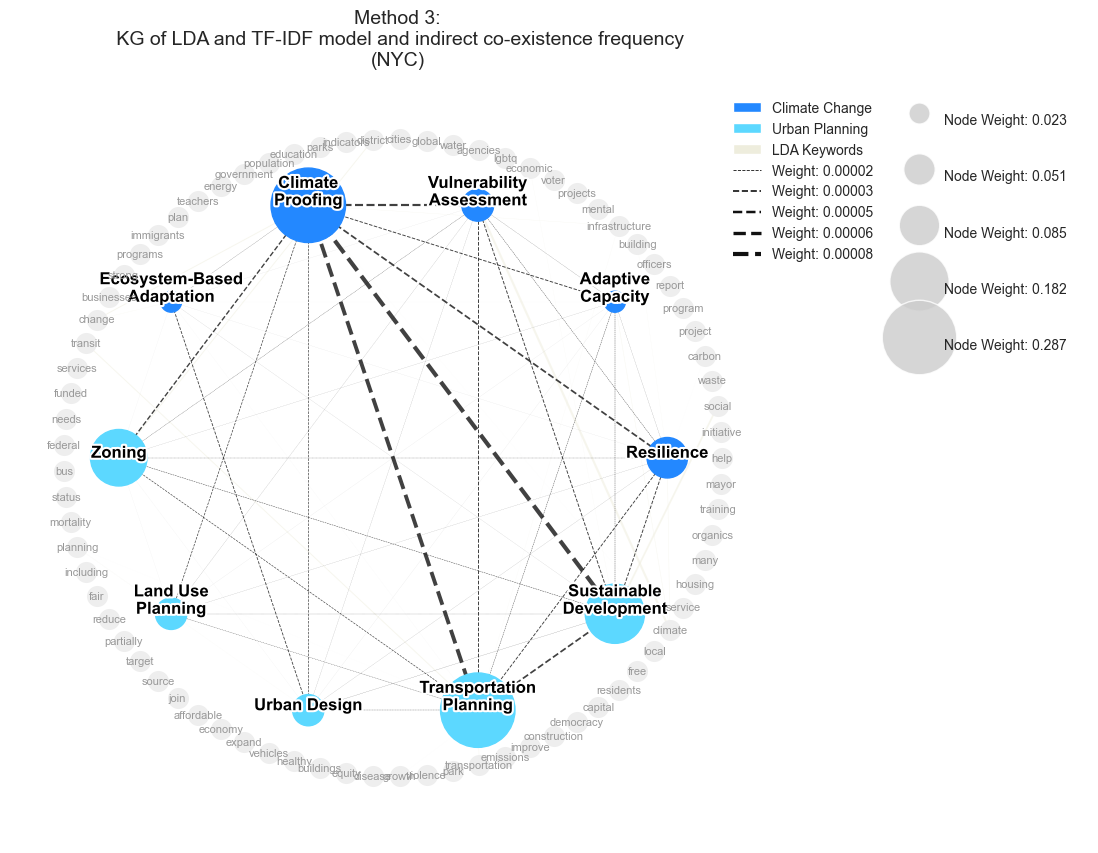

In [38]:
import textwrap
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import textwrap

pos = {}

# 构建图
G = nx.Graph()

# 构建节点和边
for (fixed_node, lda_keyword), score in correlation_scores.items():
    G.add_node(fixed_node, type='fixed')  # 蓝色固定节点
    G.add_node(lda_keyword, type='lda_word')  # 绿色关键词节点
    G.add_edge(fixed_node, lda_keyword, weight=score)

# 添加边及权重
for topic1, connections in topic_cooccurrence.items():
    for topic2, weight2 in connections.items():
        if weight2 > 0:  # 只添加有权重的边
            G.add_edge(topic1, topic2, weight=weight2)
# 提取边的权重
edges = G.edges(data=True)
weights = [data['weight'] for _, _, data in edges]

#########################
# 定义自定义顺序列表
custom_order = ['resilience', 'adaptive capacity', 'vulnerability assessment', 'climate proofing',
                'ecosystem-based adaptation', 'zoning', 'land use planning', 'urban design', 'transportation planning',
                'sustainable development']
#########################
# 调整 shell_layout，将内圈的半径设置为 1.5，外圈设置为 2.5
radius_inner = 5  # 控制内圈的半径
radius_outer = 6  # 控制外圈的半径（可以根据需要调整）

# 绘制布局：固定节点在内圈，关键词节点在外圈
# 获取类型为 'fixed' 的节点
fixed_node_list = [node for node, attr in G.nodes(data=True) if attr['type'] == 'fixed']
# 将节点按照 custom_order 中的顺序排列，如果节点不在 custom_order 中，保持原有顺序
fixed_node_list.sort(key=lambda x: custom_order.index(x) if x in custom_order else float('inf'))
lda_node_list = [node for node, attr in G.nodes(data=True) if attr['type'] == 'lda_word']

# 使用 shell_layout 来布局节点
shell_layout = [fixed_node_list, lda_node_list]  # 内圈：固定节点，外圈：关键词节点
pos = nx.shell_layout(G, nlist=shell_layout)  # 传递两个列表，不需要嵌套

# 调整内圈半径
for node in fixed_node_list:
    pos[node] = (pos[node][0] * radius_inner, pos[node][1] * radius_inner)

#######################
# 设置旋转角度
rotation_angle = 18 * np.pi / 180  # 36度转换为弧度
# 旋转内圈节点
for node in fixed_node_list:
    x, y = pos[node]  # 获取原始坐标
    r = np.sqrt(x ** 2 + y ** 2)  # 计算半径
    theta = np.arctan2(y, x)  # 计算原始角度
    theta += rotation_angle  # 增加36度的旋转
    # 将新的极坐标转换为笛卡尔坐标
    pos[node] = (r * np.cos(theta), r * np.sin(theta))
#######################
# 手动设置节点的位置：内圈的节点（fixed_node_list）和外圈的节点（lda_node_list）

# 按照自定义顺序放置固定节点在内圈
for i, node in enumerate(fixed_node_list):
    angle = 2 * np.pi * i / len(fixed_node_list)
    pos[node] = (radius_inner * np.cos(angle), radius_inner * np.sin(angle))

# 将 LDA 关键词节点放置在外圈
for i, node in enumerate(lda_node_list):
    angle = 2 * np.pi * i / len(lda_node_list)
    pos[node] = (radius_outer * np.cos(angle), radius_outer * np.sin(angle))
# 绘制图形
plt.figure(figsize=(10, 10), facecolor="#ffffff")
# 去掉坐标轴
plt.axis('off')  # 关闭坐标轴

k = 10000
j=3
# 绘制前五个固定节点（深蓝色，中心较大）
nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=list(fixed_nodes_list.keys())[:5],  # 前五个节点
    node_color="#2388FF",
    node_size=[size * k for size in sizes[:5]],  # 计算前五个节点的大小
    label="climate adaptation"
)

# 绘制剩余的固定节点（浅蓝色，中心较大）
nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=list(fixed_nodes_list.keys())[5:],  # 剩余节点
    node_color="#5CD8FF",
    node_size=[size * k for size in sizes[5:]],  # 计算剩余节点的大小
    label="urban planning"
)

node_size=[size * k for size in sizes]
print(f'node_size:{node_size}')

# 绘制标签并添加描边
for node in fixed_node_list:
    x, y = pos[node]  # 获取节点的位置
    # 自动按空格换行，限制每行最大字符数（例如：15个字符）
    wrapped_text = textwrap.fill(node.title(), width=15)  # 每行最多 15 个字符
    # 自动按空格换行，限制每行最大字符数（例如：15个字符
    text = plt.text(
        x, y, wrapped_text, fontsize=12, fontweight='bold', ha='center', color='black'
    )
    text.set_path_effects([
        path_effects.Stroke(linewidth=3, foreground='white'),  # 添加白色描边
        path_effects.Normal()  # 恢复正常文字效果
    ])

# 绘制关键词节点（灰色，外围较小）
nx.draw_networkx_nodes(
    G, pos, nodelist=lda_node_list, node_color="#EEEEEE", node_size=200, label="LDA Keywords"
)
nx.draw_networkx_labels(G, pos, labels={node: node for node in lda_node_list}, font_size=8, font_color="#999999")

normalized_weights = [
    0 + (weight1 - min_weight) / (max_weight - min_weight) * 1 for weight1 in weights1
]
#########

# 生成用于图例的示例边权重
example_weights = np.linspace(min_weight, max_weight, 6)  # 生成五个等间隔的权重
example_widths = [
    0 + (w - min_weight) / (max_weight - min_weight) * 1 for w in example_weights
]
# 移除第一个权重和对应的宽度
example_weights = example_weights[1:]
example_widths = example_widths[1:]
print(min_weight)
print(f'normalized_weights{normalized_weights}')

# 初始化边的分组
blue_edges = []  # 满足条件的边
gray_edges = []  # 不满足条件的边
blue_weights = []  # 蓝色边对应的权重
gray_weights = []  # 灰色边对应的权重

# 遍历所有边并进行分类
for u, v, d in G.edges(data=True):
    weight = d.get("weight", 1)  # 默认权重为 1
    # 如果两个节点都在 custom_order 中，设为蓝色
    if u in custom_order and v in custom_order:
        blue_edges.append((u, v))
        blue_weights.append(weight)
    # 如果不在 custom_order 中，并且权重不为 0，设为灰色
    elif weight != 0:
        gray_edges.append((u, v))
        gray_weights.append(weight)

# 绘制灰色边
nx.draw_networkx_edges(
    G,
    pos,
    edgelist=gray_edges,
    edge_color="#EEEDDD",
    width=[nor*3 for nor in normalized_weights],  # 根据权重调整宽度
    alpha=0.5,
)


# 绘制深灰色边
nx.draw_networkx_edges(
    G,
    pos,
    edgelist=blue_edges,
    edge_color="#111111",
    width=[nor*j if nor >= 0.00002 else 0.2*j for nor in normalized_weights],  # 根据权重调整宽度
    style='--',
    alpha=0.8,
)

# 添加图例
legend_elements = [
    Patch(facecolor='#2388FF', edgecolor='#ffffff', label='Climate Change'),  # 蓝色固定节点
    Patch(facecolor='#5CD8FF', edgecolor='#ffffff', label='Urban Planning'),   # 黄色固定节点
    Patch(facecolor='#EEEDDD', edgecolor='#ffffff', label='LDA Keywords'),              # LDA 关键词节点
]

# 添加边权重示例
for w, width in zip(example_weights, example_widths):
    legend_elements.append(
        Line2D(
            [0], [0],
            color='#111111',
            lw=width*j,
            label=f"Weight: {w:.5f}",
            linestyle='--',
        )
    )

# 调整图例中的节点大小计算
legend_node_sizes = [np.sqrt(size*k) for size in sizes]  # 使用与图中节点相同的缩放因子
legend_node_weights = [node_weight for node_weight in sizes]
# 对节点权重和大小去重并排序
unique_weights_sizes = sorted(set(zip(legend_node_weights, legend_node_sizes)))
sorted_weights, sorted_sizes = zip(*unique_weights_sizes)
# 限制图例中最多五个节点，确保头尾都在
max_legend_items = 6

if len(sorted_weights) > max_legend_items:
    # 包含头尾节点
    first_weight, last_weight = sorted_weights[0], sorted_weights[-1]
    first_size, last_size = sorted_sizes[0], sorted_sizes[-1]

    # 从中间节点中等间距选取剩余的节点
    middle_weights = sorted_weights[1:-1]
    middle_sizes = sorted_sizes[1:-1]
    num_middle_items = max_legend_items - 2  # 除去头尾的数量

    if num_middle_items > 0:
        step = max(1, len(middle_weights) // num_middle_items)  # 计算步长
        sampled_indices = list(range(0, len(middle_weights), step))[:num_middle_items]
        middle_weights = [middle_weights[i] for i in sampled_indices]
        middle_sizes = [middle_sizes[i] for i in sampled_indices]
    else:
        middle_weights, middle_sizes = [], []

    # 合并头部、中间和尾部
    sorted_weights =  middle_weights + [last_weight]
    sorted_sizes =  middle_sizes + [last_size]

node_size_legend = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markersize=size,
        markerfacecolor='#CCCCCC',
        alpha=0.8,
        label=f"Node Weight: {weight:.3f}"
    )
    for weight, size in zip(sorted_weights, sorted_sizes)  # 确保传递相应的权重和大小
]
legend_elements.extend(node_size_legend)

# 绘制节点+边图例
node_legend = plt.legend(
    handles=legend_elements[:8],  # 节点相关图例
    loc="upper right",
    bbox_to_anchor=(1.15, 1),
    fontsize=10,
    frameon=False,
    borderpad=1.5      # 增加边框和内容之间的填充
)
plt.gca().add_artist(node_legend)  # 手动添加第一个图例

# 绘制节点权重图例
plt.legend(
    handles=legend_elements[8:],  # 边权重相关图例
    loc="upper right",
    bbox_to_anchor=(1.4, 1),
    fontsize=10,
    frameon=False,
    labelspacing=1.2,  # 增加标签之间的垂直间距
    handleheight=4,    # 增加句柄（marker）高度
    borderpad=1.5      # 增加边框和内容之间的填充
)
# 添加标题
plt.title("Method 3:"
          "\n KG of LDA and TF-IDF model and indirect co-existence frequency"
          "\n(NYC)", fontsize=14)

plt.show()